<a href="https://colab.research.google.com/github/hyui02/miniproject1/blob/main/%EC%98%81%ED%99%94%EA%B4%80%EA%B0%9D_%EA%B4%80%EB%9E%8C%EB%93%B1%EA%B8%89_%ED%8F%AC%EC%BB%A4%EC%8B%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0단계 변수 확인
관람등급과 개봉 연도가 분

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train = pd.read_csv('/content/movies_train.csv')

!apt-get -qq -y install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [2]:
train['release_time'] = pd.to_datetime(train['release_time'])
train['release_year'] = train['release_time'].dt.year
rating_order = ['전체 관람가', '12세 관람가', '15세 관람가', '청소년 관람불가']

print(train['screening_rat'].isna().sum())
print(train['screening_rat'].value_counts().loc[rating_order])
print(train['release_year'].value_counts().sort_index())

0
screening_rat
전체 관람가       92
12세 관람가     102
15세 관람가     202
청소년 관람불가    204
Name: count, dtype: int64
release_year
2010     90
2011     80
2012     88
2013     95
2014    127
2015    120
Name: count, dtype: int64


#1단계 연도별 관람등급 구성

screening_rat  전체 관람가  12세 관람가  15세 관람가  청소년 관람불가
release_year                                     
2010             20.0     17.8     30.0      32.2
2011             23.8     17.5     38.8      20.0
2012              9.1     20.5     50.0      20.5
2013             12.6     13.7     33.7      40.0
2014             14.2     17.3     27.6      40.9
2015             14.2     15.8     27.5      42.5


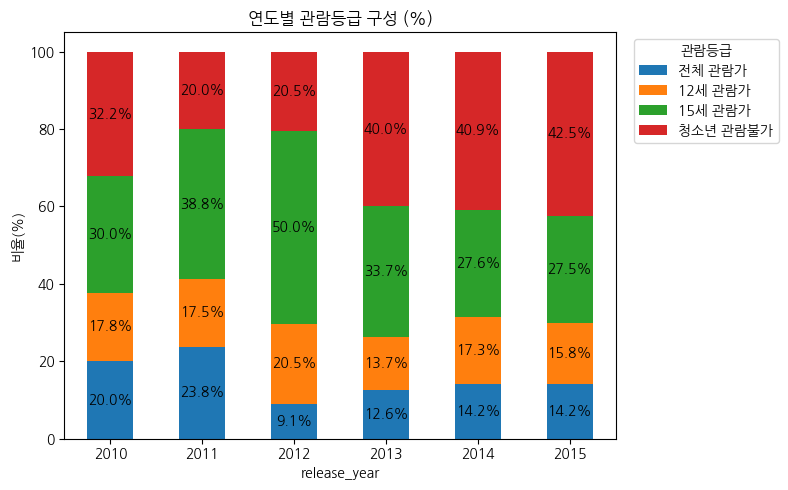

In [3]:
rating_ratio = pd.crosstab(train['release_year'], train['screening_rat'], normalize='index')[rating_order] * 100
print(rating_ratio.round(1))

ax = rating_ratio.plot(kind='bar', stacked=True, figsize=(8, 5), rot=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center')
plt.title('연도별 관람등급 구성 (%)')
plt.ylabel('비율(%)')
plt.legend(title='관람등급', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

#2단게 장르별 청소년 관람불가 비율의 변화

In [4]:
#기간 나누기와 장르 고르기: 연도별로 나누면 장르 편수가 너무 적으므로 2010-2012/2013-2015로 나눔
train['period'] = np.where(train['release_year'] <= 2012, '2010~2012년', '2013~2015년')
train['is_adult'] = train['screening_rat'] == '청소년 관람불가'

In [6]:
count = pd.crosstab(train['genre'], train['period'])
rate = train.groupby(['genre', 'period'])['is_adult'].mean().unstack() * 100
stat = pd.DataFrame({'n_early': count['2010~2012년'], 'n_late': count['2013~2015년'],
                     'early': rate['2010~2012년'], 'late': rate['2013~2015년']}).dropna()
stat['change'] = stat['late'] - stat['early']
stat['group'] = np.where(stat['n_early'] + stat['n_late'] < 20, '20편 미만',
                         np.where(stat['change'] >= 10, '20편 이상, +10%p 이상', '20편 이상, +10%p 미만'))
stat['label'] = stat.index + ' (' + stat['n_early'].astype(str) + ' / ' + stat['n_late'].astype(str) + '편)'
stat = stat.sort_values('change', ascending=False)
print(stat.round(1))

        n_early  n_late  early  late  change             group  \
genre                                                            
멜로/로맨스       27      51   25.9  76.5    50.5  20편 이상, +10%p 이상   
미스터리          5      12   20.0  58.3    38.3            20편 미만   
코미디          29      24    6.9  41.7    34.8  20편 이상, +10%p 이상   
드라마         102     119   26.5  42.9    16.4  20편 이상, +10%p 이상   
느와르          11      16   63.6  68.8     5.1  20편 이상, +10%p 미만   
다큐멘터리        40      53    0.0   1.9     1.9  20편 이상, +10%p 미만   
뮤지컬           2       3    0.0   0.0     0.0            20편 미만   
공포           15      27   53.3  51.9    -1.5  20편 이상, +10%p 미만   
애니메이션         8      13   25.0   7.7   -17.3  20편 이상, +10%p 미만   
액션           14      14   50.0  28.6   -21.4  20편 이상, +10%p 미만   
SF            5       8   40.0  12.5   -27.5            20편 미만   

                    label  
genre                      
멜로/로맨스  멜로/로맨스 (27 / 51편)  
미스터리       미스터리 (5 / 12편)  
코미디        코미디 (29 / 24편)  
드

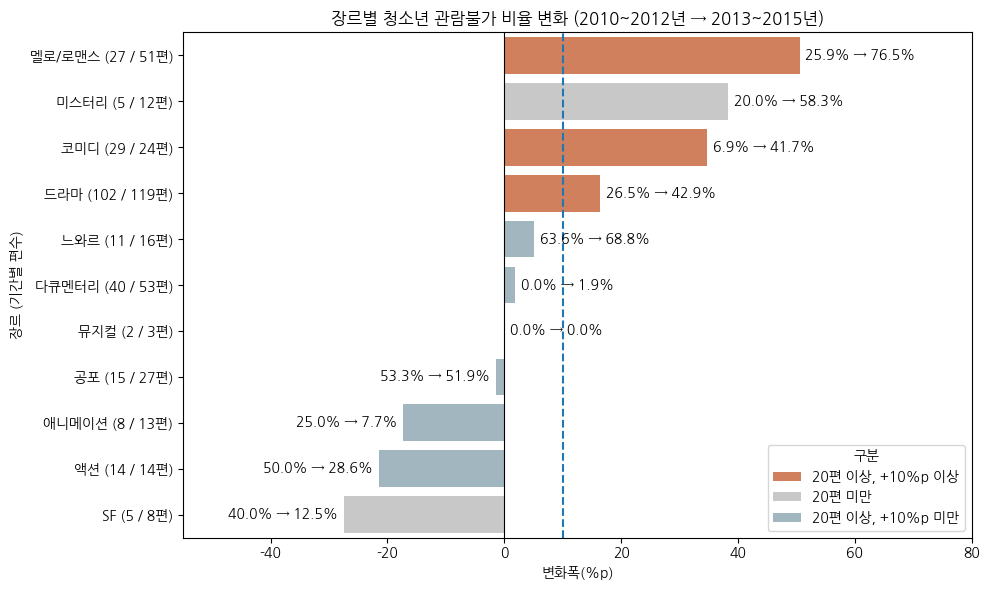

In [7]:
palette = {'20편 이상, +10%p 이상': '#E4794A', '20편 이상, +10%p 미만': '#9DB8C4', '20편 미만': '#C8C8C8'}
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='change', y='label', hue='group', data=stat, palette=palette, dodge=False)
for i, (_, r) in enumerate(stat.iterrows()):
    ax.text(r['change'] + (1 if r['change'] >= 0 else -1), i, f"{r['early']:.1f}% → {r['late']:.1f}%",
            va='center', ha='left' if r['change'] >= 0 else 'right')
plt.axvline(0, color='black', linewidth=0.8)
plt.axvline(10, linestyle='--')
plt.xlim(-55, 80)
plt.title('장르별 청소년 관람불가 비율 변화 (2010~2012년 → 2013~2015년)')
plt.xlabel('변화폭(%p)')
plt.ylabel('장르 (기간별 편수)')
plt.legend(title='구분', loc='lower right')
plt.tight_layout()
plt.show()

2010 ~2012년과 2013 ~2015년의 청소년 관람불가 비율 차이가 진짜 변화인지, 편수가 적어서 우연히 생긴 차이인지 확인해본다.

In [11]:
from scipy.stats import fisher_exact

genres = ['멜로/로맨스', '코미디', '드라마', '공포', '느와르', '액션']
rows = []
for genre in genres:
    g = train[train['genre'] == genre]
    early = g[g['release_year'] <= 2012]['is_adult']
    late = g[g['release_year'] >= 2013]['is_adult']
    p = fisher_exact([[early.sum(), (~early).sum()], [late.sum(), (~late).sum()]])[1]
    rows.append({'genre': genre, 'early': f'{early.sum()}/{len(early)}',
                 'late': f'{late.sum()}/{len(late)}', 'p_value': round(p, 4)})
print(pd.DataFrame(rows))

    genre   early    late  p_value
0  멜로/로맨스    7/27   39/51   0.0000
1     코미디    2/29   10/24   0.0035
2     드라마  27/102  51/119   0.0116
3      공포    8/15   14/27   1.0000
4     느와르    7/11   11/16   1.0000
5      액션    7/14    4/14   0.4401


        2011년까지 vs 이후  2012년까지 vs 이후  2013년까지 vs 이후
멜로/로맨스           33.3           50.5           46.2
코미디              16.0           34.8           27.9
드라마              10.0           16.4           18.7
공포                3.3           -1.5            0.5
느와르              -6.4            5.1            0.0
액션               -7.6          -21.4          -20.0


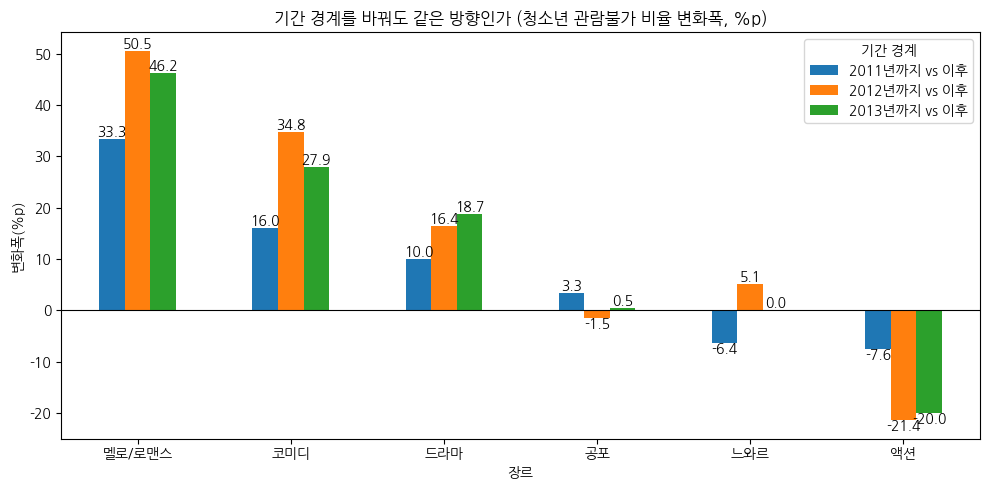

In [12]:
sub = train[train['genre'].isin(genres)]
change = pd.DataFrame(index=genres)
for cut in [2011, 2012, 2013]:
    rate = sub.groupby(['genre', sub['release_year'] > cut])['is_adult'].mean().unstack() * 100
    change[f'{cut}년까지 vs 이후'] = (rate[True] - rate[False]).loc[genres]
print(change.round(1))

ax = change.plot(kind='bar', figsize=(10, 5), rot=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('기간 경계를 바꿔도 같은 방향인가 (청소년 관람불가 비율 변화폭, %p)')
plt.xlabel('장르')
plt.ylabel('변화폭(%p)')
plt.legend(title='기간 경계')
plt.tight_layout()
plt.show()

#가장 변화가 있는 멜로/로맨스를 기준으로 확인

In [ ]:
sub = train[train['genre'].isin(genres)]
change = pd.DataFrame(index=genres)
for cut in [2011, 2012, 2013]:
    rate = sub.groupby(['genre', sub['release_year'] > cut])['is_adult'].mean().unstack() * 100
    change[f'{cut}년까지 vs 이후'] = (rate[True] - rate[False]).loc[genres]
print(change.round(1))

ax = change.plot(kind='bar', figsize=(10, 5), rot=0)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('기간 경계를 바꿔도 같은 방향인가 (청소년 관람불가 비율 변화폭, %p)')
plt.xlabel('장르')
plt.ylabel('변화폭(%p)')
plt.legend(title='기간 경계')
plt.tight_layout()
plt.show()

In [9]:
romance = train[train['genre'] == '멜로/로맨스']
year_stat = romance.groupby('release_year')['is_adult'].agg(n='size', adult_n='sum')
year_stat['non_adult_n'] = year_stat['n'] - year_stat['adult_n']
year_stat['adult_pct'] = year_stat['adult_n'] / year_stat['n'] * 100
print(year_stat.round(1))

               n  adult_n  non_adult_n  adult_pct
release_year                                     
2010          11        5            6       45.5
2011           7        1            6       14.3
2012           9        1            8       11.1
2013          12        7            5       58.3
2014          18       15            3       83.3
2015          21       17            4       81.0


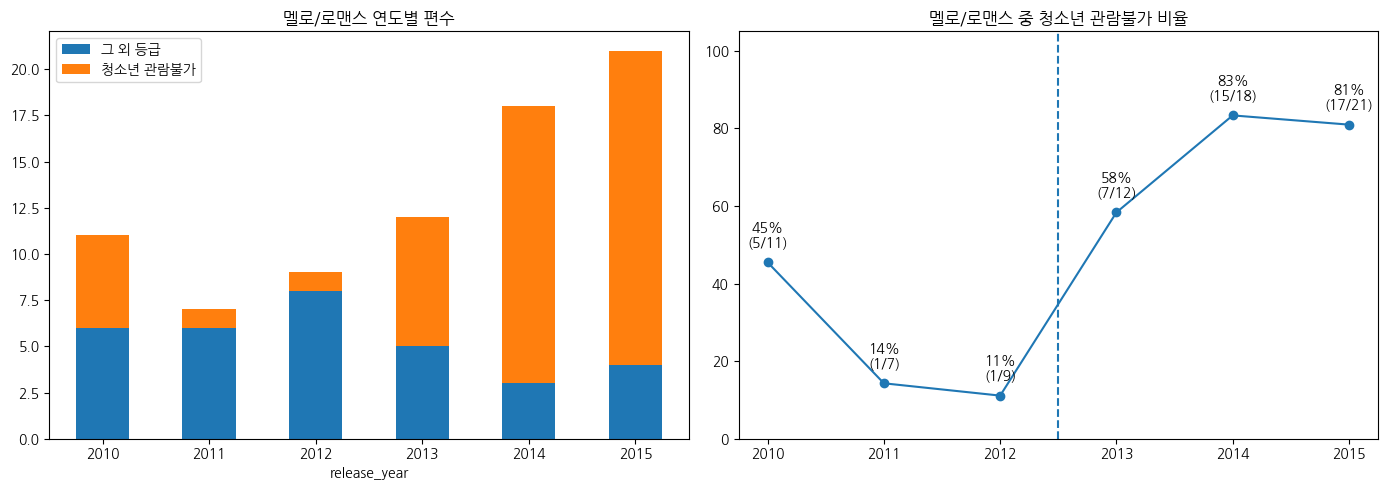

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
year_stat[['non_adult_n', 'adult_n']].plot(kind='bar', stacked=True, ax=ax[0], rot=0)
ax[0].set_title('멜로/로맨스 연도별 편수')
ax[0].legend(['그 외 등급', '청소년 관람불가'])

ax[1].plot(year_stat.index, year_stat['adult_pct'], marker='o')
for year, row in year_stat.iterrows():
    ax[1].text(year, row['adult_pct'] + 4,
               f"{row['adult_pct']:.0f}%\n({row['adult_n']:.0f}/{row['n']:.0f})", ha='center')
ax[1].axvline(2012.5, linestyle='--')
ax[1].set_ylim(0, 105)
ax[1].set_title('멜로/로맨스 중 청소년 관람불가 비율')
plt.tight_layout()
plt.show()

#3단계

In [13]:
mix = pd.crosstab(train['genre'], train['period'], normalize='columns') * 100
main = ['드라마', '다큐멘터리', '멜로/로맨스', '코미디', '공포', '액션', '느와르']
print(mix.loc[main].round(1))

period  2010~2012년  2013~2015년
genre                         
드라마           39.5        34.8
다큐멘터리         15.5        15.5
멜로/로맨스        10.5        14.9
코미디           11.2         7.0
공포             5.8         7.9
액션             5.4         4.1
느와르            4.3         4.7


In [14]:
rate = train.groupby(['genre', 'period'])['is_adult'].mean().unstack().fillna(0)
actual_early = train[train['period'] == '2010~2012년']['is_adult'].mean() * 100
actual_late = train[train['period'] == '2013~2015년']['is_adult'].mean() * 100
fixed_mix = (mix['2010~2012년'] / 100 * rate['2013~2015년']).sum() * 100

result = pd.Series({'2010~2012년\n(실제)': actual_early,
                    '2013~2015년\n(장르 구성을 2010~2012년과 같게 가정)': fixed_mix,
                    '2013~2015년\n(실제)': actual_late})
print(result.round(1))

2010~2012년\n(실제)                          24.4
2013~2015년\n(장르 구성을 2010~2012년과 같게 가정)    39.0
2013~2015년\n(실제)                          41.2
dtype: float64


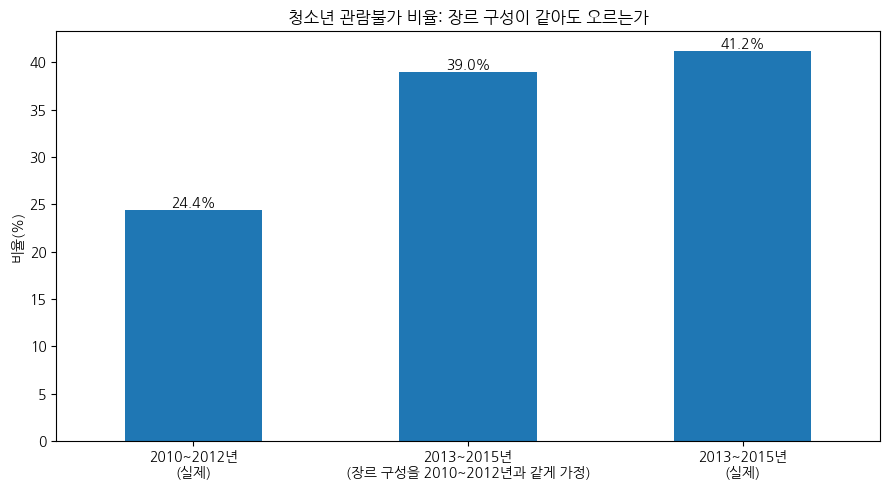

In [15]:
plt.figure(figsize=(9, 5))
ax = result.plot(kind='bar', rot=0)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.title('청소년 관람불가 비율: 장르 구성이 같아도 오르는가')
plt.ylabel('비율(%)')
plt.tight_layout()
plt.show()